# Module 03 — Convolutions / LeNet-5 (weight sharing · locality · feature maps)

Modules 01–02 built a trainable MLP — but fed it images as 784 loose numbers,
throwing away the single most important fact about a picture: **nearby pixels
belong together**. This module keeps the geometry. A small learned **kernel**
slides across the image, asking the same question at every position; the answers
form a **feature map**; **pooling** keeps the strongest responses. Stack that
twice, and a 44,426-parameter network beats the 101,770-parameter MLP on MNIST.

This is LeCun, Bottou, Bengio & Haffner (1998), *Gradient-Based Learning Applied
to Document Recognition* — implemented with the Module-02 toolkit (ReLU, He,
Adam) in place of the 1998 machinery, which gets its own historical corner in §9.

This notebook rebuilds the mechanism with inline plots, then verifies itself
against the canonical `python/lenet.py` and the C mirror, and finally
cross-checks the whole thing against PyTorch, TensorFlow, and Keras.

In [1]:
import os, sys, math, time
import numpy as np
import matplotlib.pyplot as plt

# Locate the repo root whether Jupyter was launched from it or the module folder.
def _find_repo():
    here = os.getcwd()
    cands = [here] + [os.path.abspath(os.path.join(here, *(['..'] * k))) for k in range(1, 6)]
    for base in cands:
        if os.path.isdir(os.path.join(base, 'lib', 'python', 'nanograd')):
            return base
    return here

REPO = _find_repo()
TOPIC = os.path.join(REPO, 'topics', '03-lenet')
sys.path.insert(0, os.path.join(REPO, 'lib', 'python'))   # nanograd
sys.path.insert(0, os.path.join(TOPIC, 'python'))          # canonical lenet.py
sys.path.insert(0, os.path.join(TOPIC, 'tests'))           # check_utils
sys.path.insert(0, os.path.join(REPO, 'data'))             # get_mnist

import nanograd as ng
import lenet as canon
from check_utils import rel_error, eval_numerical_gradient, eval_numerical_gradient_array
np.set_printoptions(precision=4, suppress=True)
print('nanograd now includes:', [x for x in ng.__all__ if x in
      ('Conv2D', 'MaxPool2D', 'AvgPool2D', 'Flatten', 'im2col', 'col2im')])

nanograd now includes: ['Conv2D', 'MaxPool2D', 'AvgPool2D', 'Flatten', 'im2col', 'col2im']


## 1. The bars toy: the smallest problem where locality pays

16 noisy 8×8 images, each containing one bright bar — vertical (class 0) or
horizontal (class 1). An MLP can solve this only by memorizing pixel positions;
a single oriented 3×3 kernel, slid everywhere, solves it *structurally*. This is
also the C↔Python agreement problem: `c/lenet.c` regenerates exactly these
images from the same RNG stream.

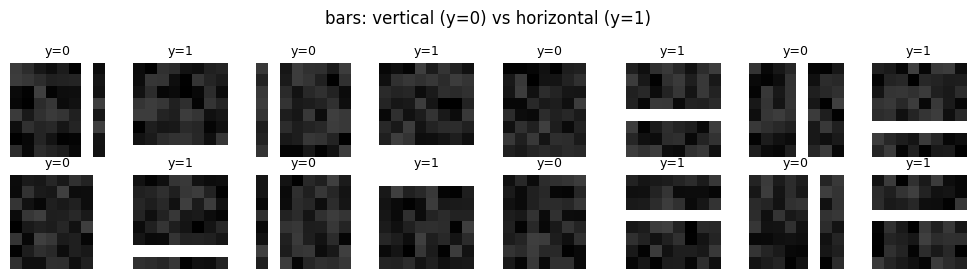

X: (16, 1, 8, 8)  y: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1]


In [2]:
Xb, yb = canon.make_bars()
fig, axes = plt.subplots(2, 8, figsize=(10, 2.8))
for i, ax in enumerate(axes.flat):
    ax.imshow(Xb[i, 0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'y={yb[i]}', fontsize=9)
    ax.axis('off')
fig.suptitle('bars: vertical (y=0) vs horizontal (y=1)')
plt.tight_layout(); plt.show()
print('X:', Xb.shape, ' y:', yb.tolist())

## 2. The convolution: one small kernel, asked everywhere

The operation itself, straight from its definition (`naive_conv2d_forward` in
`python/lenet.py` — explicit loops, no tricks):

$$Y[i,f,u,v] \;=\; b_f + \sum_{c,p,q} K[f,c,p,q]\; X[i,c,u+p,v+q]$$

A *valid* convolution shrinks the map: a 5×5 kernel on 28×28 gives
$28-5+1 = 24$. (Like every modern framework, we implement **cross-correlation**
— no kernel flip; the flip will reappear on its own in the backward pass.)
Hand-designed kernels show what "asking a question everywhere" means: an edge
kernel lights up where strokes of its orientation exist.

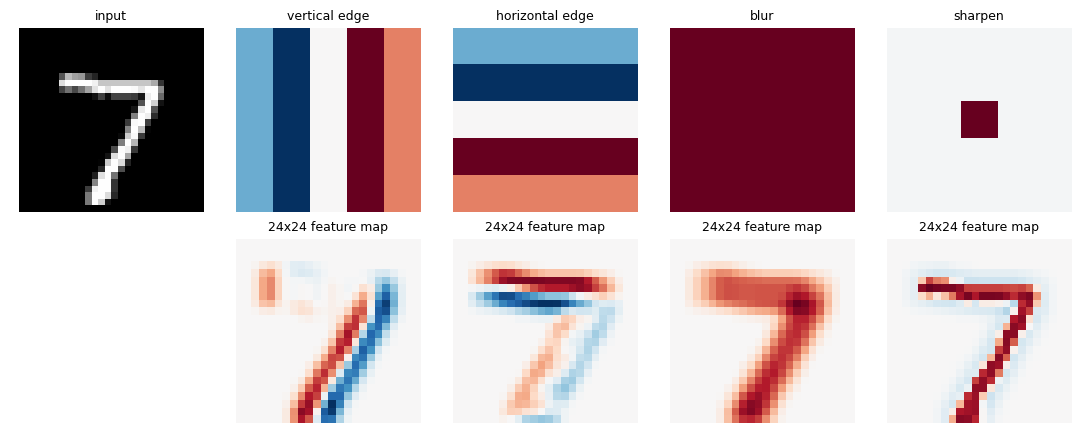

output size: 28 - 5 + 1 = 24


In [3]:
Xtr_img, ytr_img, Xte_img, yte_img = canon.load_mnist_images()
digit = Xte_img[0:1]                       # a real handwritten 7, (1,1,28,28)

KS = 5
presets = {
    'vertical edge':   np.tile(np.array([-1., -2., 0., 2., 1.]) / 8., (KS, 1)),
    'horizontal edge': np.tile(np.array([-1., -2., 0., 2., 1.]) / 8., (KS, 1)).T,
    'blur':            np.full((KS, KS), 1. / 25.),
    'sharpen':         np.full((KS, KS), -1. / 25.) + np.eye(KS)[2:3].T @ np.eye(KS)[2:3] * 2,
}
fig, axes = plt.subplots(2, len(presets) + 1, figsize=(11, 4.4))
axes[0, 0].imshow(digit[0, 0], cmap='gray'); axes[0, 0].set_title('input', fontsize=9)
axes[1, 0].axis('off')
for j, (name, k) in enumerate(presets.items(), start=1):
    Y = canon.naive_conv2d_forward(digit, k[None, None], np.zeros(1))
    m = np.abs(Y).max()
    axes[0, j].imshow(k, cmap='RdBu_r', vmin=-np.abs(k).max(), vmax=np.abs(k).max())
    axes[0, j].set_title(name, fontsize=9)
    axes[1, j].imshow(Y[0, 0], cmap='RdBu_r', vmin=-m, vmax=m)
    axes[1, j].set_title(f'{Y.shape[2]}x{Y.shape[3]} feature map', fontsize=9)
for ax in axes.flat: ax.axis('off')
plt.tight_layout(); plt.show()
print('output size: 28 - 5 + 1 =', 28 - 5 + 1)

## 3. The backward pass, derived and checked

Each output cell touched $K[f,c,p,q]$ once (times a pixel) and each pixel once
(times a kernel tap), so the chain rule runs those products back:

- $\partial L/\partial b_f = \sum_{i,u,v} dY[i,f,u,v]$
- $\partial L/\partial K[f,c,p,q] = \sum_{i,u,v} dY[i,f,u,v] \, X[i,c,u{+}p,v{+}q]$
  — the input **correlated with the upstream gradient** (the forward op again,
  roles swapped)
- $\partial L/\partial X[i,c,h,w] = \sum_{f,p,q} dY[i,f,h{-}p,w{-}q] \, K[f,c,p,q]$
  — a *full* correlation with the **flipped kernel**: the true convolution we
  skipped in forward reappears by itself.

As in every module: the analytic gradients must match finite differences.

In [4]:
rng = np.random.default_rng(0)
Xs = rng.standard_normal((2, 1, 5, 5))
Ks = rng.standard_normal((2, 1, 3, 3))
bs = rng.standard_normal(2)
dY = rng.standard_normal((2, 2, 3, 3))

dX, dK, db = canon.naive_conv2d_backward(Xs, Ks, dY)
for name, analytic, wrt in (('dK', dK, Ks), ('db', db, bs), ('dX', dX, Xs)):
    numeric = eval_numerical_gradient_array(
        lambda _: canon.naive_conv2d_forward(Xs, Ks, bs), wrt, dY)
    err = rel_error(analytic, numeric)
    print(f'  {name}: rel_error = {err:.2e}')
    assert err < 1e-6
print('conv backward matches finite differences.')

  dK: rel_error = 3.34e-09
  db: rel_error = 2.10e-11
  dX: rel_error = 5.38e-11
conv backward matches finite differences.


## 4. Pooling: keep the strongest response

Max pooling summarizes each 2×2 window by its strongest response — "was the
feature here at all?" — halving the resolution and buying a little translation
tolerance. Its backward is pure **routing**: the winner takes the whole
gradient (the same mask idea as ReLU). Average pooling — LeNet-5's original
choice — keeps the mean and spreads the gradient evenly. Both live in
`nanograd` now; max is our canonical choice, avg powers §9's ablation.

(The finite-difference check uses continuous random inputs: max-pool's kinks
— exact ties inside a window — are a measure-zero event a random draw never
hits.)

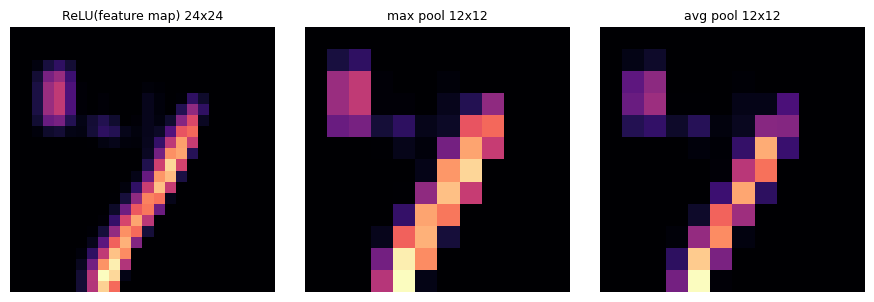

nonzero grads per window (should be 1.0): 1.0
  MaxPool2D: dX rel_error = 3.28e-12
  AvgPool2D: dX rel_error = 1.89e-11


In [5]:
Y = canon.naive_conv2d_forward(digit, presets['vertical edge'][None, None], np.zeros(1))
relu = np.maximum(Y, 0.0)
mx, av = ng.MaxPool2D(2), ng.AvgPool2D(2)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (img, title) in zip(axes, [(relu[0, 0], 'ReLU(feature map) 24x24'),
                                   (mx.forward(relu)[0, 0], 'max pool 12x12'),
                                   (av.forward(relu)[0, 0], 'avg pool 12x12')]):
    ax.imshow(img, cmap='magma'); ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

# Routing: max-pool's backward sends each gradient to exactly one input cell.
Xp = rng.standard_normal((2, 3, 6, 6))
dYp = rng.standard_normal((2, 3, 3, 3))
mx.forward(Xp)
dXp = mx.backward(dYp)
print('nonzero grads per window (should be 1.0):',
      float((dXp.reshape(2, 3, 3, 2, 3, 2) != 0).sum(axis=(3, 5)).mean()))
for Pool in (ng.MaxPool2D, ng.AvgPool2D):
    pool = Pool(2)
    pool.forward(Xp)
    err = rel_error(pool.backward(dYp),
                    eval_numerical_gradient_array(lambda _: pool.forward(Xp), Xp, dYp))
    print(f'  {Pool.__name__}: dX rel_error = {err:.2e}')
    assert err < 1e-6

## 5. im2col: convolution is a matrix multiply in disguise

The naive quadruple loop is the definition, but NumPy pays a Python-interpreter
toll per iteration. `im2col` copies every 5×5 patch out as a **row** of one big
matrix, so scoring all patches against all filters becomes a single matmul —
the one operation computers are fastest at. Pixels get duplicated (an interior
pixel appears in 25 rows); that redundancy is the price of speed. The library's
`Conv2D` uses this path — and must agree with the naive definition to 1e-12.

In [6]:
conv = ng.Conv2D(1, 6, 5, 5)
ng.he_normal_conv2d(conv.K, ng.Rng(7))
batch = Xte_img[:32]

t0 = time.perf_counter(); Y_naive = canon.naive_conv2d_forward(batch, conv.K, conv.b)
t_naive = time.perf_counter() - t0
t0 = time.perf_counter(); Y_fast = conv.forward(batch)
t_fast = time.perf_counter() - t0

print(f'max|im2col - naive| = {np.abs(Y_fast - Y_naive).max():.2e}')
assert np.abs(Y_fast - Y_naive).max() < 1e-12
print(f'naive: {t_naive*1e3:7.1f} ms   im2col: {t_fast*1e3:6.1f} ms   '
      f'speedup ~{t_naive/t_fast:.0f}x  (32 images, 6 filters)')

max|im2col - naive| = 1.33e-15
naive:  2516.8 ms   im2col:    9.2 ms   speedup ~272x  (32 images, 6 filters)


## 6. Toy → trained: bars solved, and the filters became edges

Train the tiny CNN (conv 4@3×3 → ReLU → maxpool → linear) on bars with Adam.
It hits 100% in a few dozen steps — and then the payoff of a model you can
*look at*: the four learned kernels are oriented edge detectors, because that
is the only question worth asking everywhere on this data.

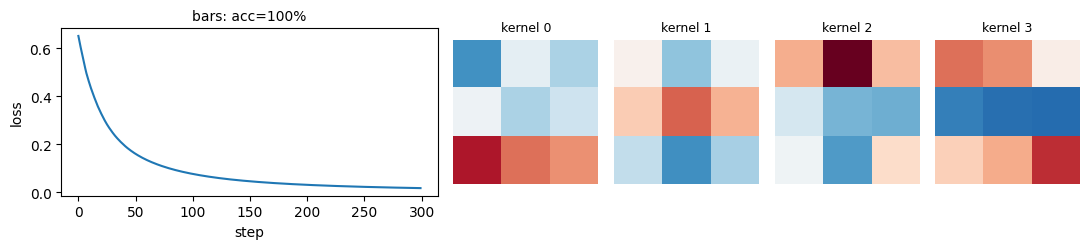

In [7]:
vnet = canon.build_toy_cnn()
loss_layer = ng.SoftmaxCrossEntropy()
opt = ng.Adam(lr=canon.ADAM_LR)
losses = []
for t in range(canon.TOY_STEPS):
    losses.append(loss_layer.forward(vnet.forward(Xb), yb))
    vnet.backward(loss_layer.backward())
    opt.step(vnet.params(), vnet.grads())
acc = float((vnet.forward(Xb).argmax(axis=1) == yb).mean())

fig, axes = plt.subplots(1, 5, figsize=(11, 2.6),
                         gridspec_kw={'width_ratios': [2.6, 1, 1, 1, 1]})
axes[0].plot(losses); axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')
axes[0].set_title(f'bars: acc={acc:.0%}', fontsize=10)
K1 = vnet.layers[0].K
m = np.abs(K1).max()
for f in range(4):
    axes[f + 1].imshow(K1[f, 0], cmap='RdBu_r', vmin=-m, vmax=m)
    axes[f + 1].set_title(f'kernel {f}', fontsize=9); axes[f + 1].axis('off')
plt.tight_layout(); plt.show()
assert acc == 1.0

## 7. Verify against the canonical `lenet.py` and the C mirror

The scalar `ToyCNN` path (explicit flat-array loops, same loop nests as
`lib/c/nanograd/conv.c`) is the C↔Python agreement gate. Here we confirm the
notebook sees the same fingerprint the test suite and `c/lenet.c` do.

In [8]:
fp = dict(canon.run_toy())
print(f"{'':7s}{'value':>24s}")
for k in ('loss', 'acc', 'wsum', 'k1_0', 'w2_00', 'b2_0'):
    print(f'{k:7s}{fp[k]:24.15g}')
# The C binary prints the same FINAL line; test_agreement.py asserts they match to 1e-9.
assert fp['acc'] == 1.0 and fp['loss'] < 0.05
print('OK — toy solved; matches c/lenet.c to ~1e-15 (see tests/test_agreement.py)')

                          value
loss         0.0176526873960184
acc                           1
wsum           2.06156392291757
k1_0         -0.726658512815414
w2_00        -0.171804720552331
b2_0            1.6753106305088
OK — toy solved; matches c/lenet.c to ~1e-15 (see tests/test_agreement.py)


## 8. Toy → real: LeNet on MNIST (target ≥ 98%)

The full architecture — LeNet-5's shape with the Module-02 toolkit swapped in:

    conv 6@5x5 → ReLU → maxpool → conv 16@5x5 → ReLU → maxpool
    → flatten(256) → 120 → ReLU → 84 → ReLU → 10

44,426 parameters (the Module-01 MLP had 101,770). Full 60k train set, 3
epochs, Adam — a few minutes of NumPy.

[mnist] LeNet (relu/max/he), 44426 params, 60000 train images, 3 epochs


  epoch 0  train_loss=0.2602  test_acc=0.9700  (66s)


  epoch 1  train_loss=0.0857  test_acc=0.9830  (73s)


  epoch 2  train_loss=0.0622  test_acc=0.9846  (49s)
MNIST test accuracy = 0.9846


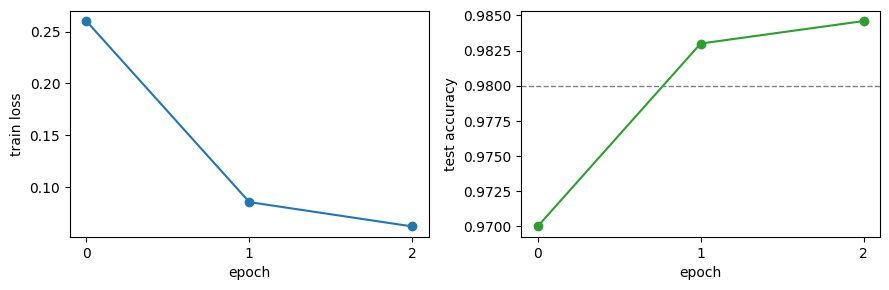

In [9]:
net, acc, hist = canon.run_mnist(verbose=True)
print(f'MNIST test accuracy = {acc:.4f}')
assert acc >= 0.98

epochs = [h[0] for h in hist]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(epochs, [h[1] for h in hist], marker='o')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('train loss'); axes[0].set_xticks(epochs)
axes[1].plot(epochs, [h[2] for h in hist], marker='o', color='tab:green')
axes[1].axhline(0.98, ls='--', c='gray', lw=1)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('test accuracy'); axes[1].set_xticks(epochs)
plt.tight_layout(); plt.show()

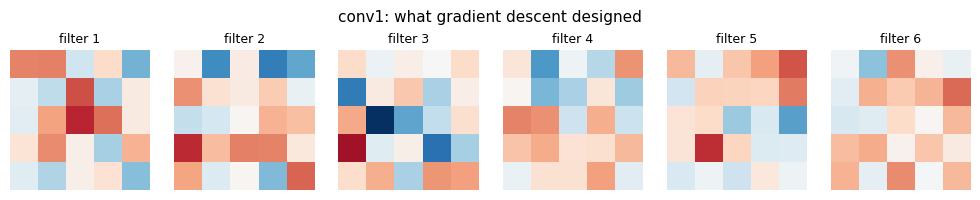

154 of 10000 test digits misclassified


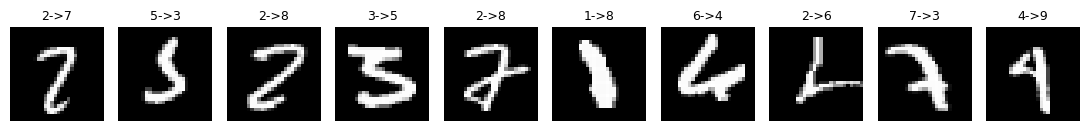

In [10]:
# What did conv1 learn? Six 5x5 kernels — edge and stroke detectors, again.
K1 = net.layers[0].K
m = np.abs(K1).max()
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for f in range(6):
    axes[f].imshow(K1[f, 0], cmap='RdBu_r', vmin=-m, vmax=m)
    axes[f].set_title(f'filter {f + 1}', fontsize=9); axes[f].axis('off')
fig.suptitle('conv1: what gradient descent designed', fontsize=11)
plt.tight_layout(); plt.show()

# And what still fools it — the misclassified tail.
pred = canon.predict(net, Xte_img)
wrong = np.flatnonzero(pred != yte_img)
print(f'{wrong.size} of {yte_img.size} test digits misclassified')
fig, axes = plt.subplots(1, 10, figsize=(11, 1.8))
for ax, i in zip(axes, wrong[:10]):
    ax.imshow(Xte_img[i, 0], cmap='gray')
    ax.set_title(f'{yte_img[i]}->{pred[i]}', fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## 9. The historical corner: what LeNet-5 actually was

The 1998 network used scaled tanh (`1.7159·tanh(2s/3)`), *trainable* average
pooling, a sparse connection table between S2 and C3 (below), and RBF output
units matched to bitmap prototypes — each a reasonable answer to 1998's
compute budget, each since replaced by a Module-02 lesson. The ablation:
the same architecture with tanh + average pooling + Xavier init (the closest
our library gets to 1998) against our ReLU/max/He build, both on a 10k subset
for 2 epochs. The old recipe still works — the new one works better, faster.

[mnist] LeNet (tanh/avg/xavier), 44426 params, 10000 train images, 2 epochs


  epoch 0  train_loss=0.8583  test_acc=0.8944  (12s)


  epoch 1  train_loss=0.3319  test_acc=0.9195  (11s)


[mnist] LeNet (relu/max/he), 44426 params, 10000 train images, 2 epochs


  epoch 0  train_loss=0.7936  test_acc=0.8903  (10s)


  epoch 1  train_loss=0.2296  test_acc=0.9427  (10s)
1998 recipe (tanh/avg/xavier): 0.9195
2020s recipe (relu/max/he):    0.9427


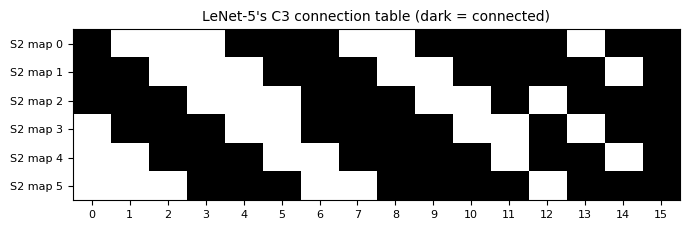

In [11]:
acc_98 = canon.run_mnist(train_n=10000, epochs=2, activation='tanh', pool='avg',
                         init='xavier', verbose=True)[1]
acc_modern = canon.run_mnist(train_n=10000, epochs=2, verbose=True)[1]
print(f'1998 recipe (tanh/avg/xavier): {acc_98:.4f}')
print(f'2020s recipe (relu/max/he):    {acc_modern:.4f}')
assert acc_98 >= 0.90 and acc_modern >= acc_98 - 0.01

# C3's connection table: which of the 6 S2 maps feed each of the 16 C3 maps.
# Sparsity broke symmetry and saved 1998-scale compute (LeCun et al., Table 1).
cols = [(0,1,2),(1,2,3),(2,3,4),(3,4,5),(0,4,5),(0,1,5),
        (0,1,2,3),(1,2,3,4),(2,3,4,5),(0,3,4,5),(0,1,4,5),(0,1,2,5),
        (0,1,3,4),(1,2,4,5),(0,2,3,5),(0,1,2,3,4,5)]
table = np.zeros((6, 16))
for j, rows in enumerate(cols):
    table[list(rows), j] = 1
plt.figure(figsize=(7, 2.4))
plt.imshow(table, cmap='Greys', aspect='auto')
plt.yticks(range(6), [f'S2 map {i}' for i in range(6)], fontsize=8)
plt.xticks(range(16), range(16), fontsize=8)
plt.title("LeNet-5's C3 connection table (dark = connected)", fontsize=10)
plt.tight_layout(); plt.show()

## 10. Framework mirrors: PyTorch, TensorFlow, Keras

The mechanism was built from scratch above. This closing section does two
things: shows the *same ideas expressed idiomatically* in each framework, and
**validates** our from-scratch code against them — PyTorch strictly (our conv
and pool are the textbook ops, gradient for gradient), TF/Keras at the result
level.

### 10.1 PyTorch — our `Conv2D` *is* `F.conv2d`, our grads *are* autograd

Strict checks, in float64. `F.conv2d` is also cross-correlation, so our kernels
drop in with no flipping. We compare forward outputs, then inject the *same*
upstream gradient and compare all three input gradients, then check the whole
toy CNN's parameter gradients against autograd.

In [12]:
import torch
import torch.nn.functional as F

# (a) forward + per-op gradients on a multi-channel conv.
conv = ng.Conv2D(2, 3, 3, 3)
conv.K[:] = rng.standard_normal(conv.K.shape); conv.b[:] = rng.standard_normal(3)
Xc = rng.standard_normal((2, 2, 6, 6)); dYc = rng.standard_normal((2, 3, 4, 4))
Y_ours = conv.forward(Xc); dX_ours = conv.backward(dYc)

Xt = torch.tensor(Xc, requires_grad=True)
Kt = torch.tensor(conv.K, requires_grad=True); bt = torch.tensor(conv.b, requires_grad=True)
Yt = F.conv2d(Xt, Kt, bt)
Yt.backward(torch.tensor(dYc))
print(f'(a) conv fwd rel_error = {rel_error(Y_ours, Yt.detach().numpy()):.2e}')
assert rel_error(Y_ours, Yt.detach().numpy()) < 1e-12
for name, ours, t in [('dK', conv.dK, Kt), ('db', conv.db, bt), ('dX', dX_ours, Xt)]:
    err = rel_error(ours, t.grad.numpy())
    print(f'(a) conv {name:2s} rel_error = {err:.2e}'); assert err < 1e-12

# (b) max pooling.
pool = ng.MaxPool2D(2)
Xp = rng.standard_normal((2, 3, 6, 6)); dYp = rng.standard_normal((2, 3, 3, 3))
P_ours = pool.forward(Xp); dXp_ours = pool.backward(dYp)
Xpt = torch.tensor(Xp, requires_grad=True)
Pt = F.max_pool2d(Xpt, 2)
Pt.backward(torch.tensor(dYp))
assert rel_error(P_ours, Pt.detach().numpy()) < 1e-12
err = rel_error(dXp_ours, Xpt.grad.numpy())
print(f'(b) maxpool fwd+dX rel_error = {err:.2e}'); assert err < 1e-12

# (c) the whole toy CNN: every parameter gradient vs autograd.
vnet2 = canon.build_toy_cnn()
conv_l, head = vnet2.layers[0], vnet2.layers[4]
ll = ng.SoftmaxCrossEntropy()
ll.forward(vnet2.forward(Xb), yb); vnet2.backward(ll.backward())
K1t = torch.tensor(conv_l.K, requires_grad=True); b1t = torch.tensor(conv_l.b, requires_grad=True)
W2t = torch.tensor(head.W, requires_grad=True); b2t = torch.tensor(head.b, requires_grad=True)
h = F.max_pool2d(F.relu(F.conv2d(torch.tensor(Xb), K1t, b1t)), 2)
loss = F.cross_entropy(h.flatten(1) @ W2t + b2t, torch.tensor(yb))
loss.backward()
for name, ours, t in [('K1', conv_l.dK, K1t), ('b1', conv_l.db, b1t),
                      ('W2', head.dW, W2t), ('b2', head.db, b2t)]:
    err = rel_error(ours, t.grad.numpy())
    print(f'(c) d{name:2s} rel_error = {err:.2e}'); assert err < 1e-10
print('PyTorch agrees: same convolution, same pooling, same gradients.')

(a) conv fwd rel_error = 2.53e-15
(a) conv dK rel_error = 9.64e-15
(a) conv db rel_error = 7.32e-16
(a) conv dX rel_error = 0.00e+00
(b) maxpool fwd+dX rel_error = 0.00e+00
(c) dK1 rel_error = 2.04e-15
(c) db1 rel_error = 5.36e-16
(c) dW2 rel_error = 2.65e-15
(c) db2 rel_error = 3.55e-16
PyTorch agrees: same convolution, same pooling, same gradients.


### 10.2 TensorFlow — the same LeNet with a `GradientTape` + Adam

In [13]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')
import tensorflow as tf

# TF wants NHWC; same LeNet, He init, Adam 1e-3, 3 epochs on the full 60k.
Xtr_tf = Xtr_img.transpose(0, 2, 3, 1).astype('float32')
Xte_tf = Xte_img.transpose(0, 2, 3, 1).astype('float32')
he = tf.keras.initializers.HeNormal
lyr = tf.keras.layers
net_tf = [lyr.Conv2D(6, 5, activation='relu', kernel_initializer=he(seed=0)),
          lyr.MaxPool2D(2),
          lyr.Conv2D(16, 5, activation='relu', kernel_initializer=he(seed=1)),
          lyr.MaxPool2D(2), lyr.Flatten(),
          lyr.Dense(120, activation='relu', kernel_initializer=he(seed=2)),
          lyr.Dense(84, activation='relu', kernel_initializer=he(seed=3)),
          lyr.Dense(10, kernel_initializer=he(seed=4))]

def forward_tf(x):
    for l in net_tf:
        x = l(x)
    return x

_ = forward_tf(Xte_tf[:1])                       # build weights
tvars = [v for l in net_tf for v in l.trainable_variables]
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
opt_tf = tf.keras.optimizers.Adam(1e-3)

@tf.function
def train_step(xb, yb_):
    with tf.GradientTape() as tape:
        loss = loss_fn(yb_, forward_tf(xb))
    opt_tf.apply_gradients(zip(tape.gradient(loss, tvars), tvars))
    return loss

ds = tf.data.Dataset.from_tensor_slices((Xtr_tf, ytr_img)).shuffle(60000, seed=0).batch(128)
for epoch in range(3):
    for xb_, yb_ in ds:
        train_step(xb_, yb_)
logits = forward_tf(Xte_tf)
tf_acc = float((tf.argmax(logits, 1).numpy() == yte_img).mean())
print(f'TensorFlow LeNet test accuracy = {tf_acc:.4f}'); assert tf_acc >= 0.98

TensorFlow LeNet test accuracy = 0.9869


### 10.3 Keras — LeNet in nine lines

In [14]:
import keras
from keras import layers

model = keras.Sequential([
    keras.Input((28, 28, 1)),
    layers.Conv2D(6, 5, activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D(2),
    layers.Conv2D(16, 5, activation='relu', kernel_initializer='he_normal'),
    layers.MaxPooling2D(2),
    layers.Flatten(),
    layers.Dense(120, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(84, activation='relu', kernel_initializer='he_normal'),
    layers.Dense(10, activation='softmax'),
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(Xtr_tf, ytr_img, epochs=3, batch_size=128, verbose=0)
keras_acc = model.evaluate(Xte_tf, yte_img, verbose=0)[1]
print(f'Keras LeNet MNIST accuracy = {keras_acc:.4f}'); assert keras_acc >= 0.98

Keras LeNet MNIST accuracy = 0.9863


---

**What we built.** Convolution and pooling, from their definitions to a
trained LeNet: `Conv2D`/`MaxPool2D`/`AvgPool2D`/`Flatten` joined `nanograd`
(in C and Python, agreeing to ~1e-15), the backward passes are still the
chain rule written out by hand, and the learned filters turned out to be the
edge detectors vision scientists spent decades describing.

**Next → Module 04 (AlexNet):** the same ideas, three orders of magnitude
more compute. What happens when convolution meets GPUs, ReLU at scale,
dropout, and a million images.